# Enhance Tabular Model using Graph-based Featurization

In this tutorial, we demonstrate how to enhance predictive performance of tabular model using graph-based featurization, when the input data is a single table. The dataset used in this tutorial comes from [Diginetca Personalized E-Commerce Search Challenge](https://competitions.codalab.org/competitions/11161). The original data is stored as multiple tables connected via different primary/foreign key relationships. To mimic the common scenarios that scientists are given data stored in a single table, we select three tables (query, product, view) from the dataset and merge them into a table of user events. The goal is to predict whether a product will be clicked by a user in a session, i.e., a click-through-rate (CTR) prediction task.

## Dataset

We have prepared the dataset as part of [`dbinfer-bench`](https://github.com/awslabs/multi-table-benchmark/).

In [1]:
import dbinfer_bench

dataset = dbinfer_bench.load_rdb_data("diginetica-events")

Dowloading dataset/multi-table/release/20240304-diginetica-events.tar ...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 760M/760M [00:06<00:00, 112MB/s]


Extracting /home/ubuntu/git-repo/tab2graph/datasets/20240304-diginetica-events.tar ...


The dataset has only one data table called `Event`.

In [2]:
import pandas as pd

events = pd.DataFrame(dataset.tables['Event'])
print(events)

           queryId  itemId               timestamp   action_type  sessionId  \
0           4920.0  169029 2016-01-01 01:47:22.804  query_result       4739   
1           4920.0  227446 2016-01-01 01:47:22.804  query_result       4739   
2           4920.0  135358 2016-01-01 01:47:22.804  query_result       4739   
3           4920.0  156264 2016-01-01 01:47:22.804  query_result       4739   
4           4920.0  231088 2016-01-01 01:47:22.804  query_result       4739   
...            ...     ...                     ...           ...        ...   
94634414  240200.0  141288 2016-10-26 01:14:59.377  query_result     112622   
94634415  240200.0  348020 2016-10-26 01:14:59.377  query_result     112622   
94634416  240200.0   54424 2016-10-26 01:14:59.377  query_result     112622   
94634417  240200.0    3700 2016-10-26 01:14:59.377  query_result     112622   
94634418  240200.0   66578 2016-10-26 01:16:43.175         click     112622   

          userId  query_duration  query_categoryId 

In [3]:
print(events.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94634419 entries, 0 to 94634418
Data columns (total 10 columns):
 #   Column            Dtype         
---  ------            -----         
 0   queryId           float64       
 1   itemId            int64         
 2   timestamp         datetime64[ns]
 3   action_type       object        
 4   sessionId         int64         
 5   userId            float64       
 6   query_duration    float64       
 7   query_categoryId  float64       
 8   item_categoryId   float64       
 9   item_pricelog2    float64       
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 7.1+ GB
None


Each row is a user event with the following attributes:
- `queryId`: The ID of the user query to the search engine.
- `itemId`: The product ID that the user interacts with.
- `userId`: User ID.
- `sessionId`: Session ID.
- `action_type`: Three possible actions.
  * `"query_result"`: The item is returned as result to the user by the search engine given their query.
  * `"view"`: The user views the product information (not necessarily need an explicit click action).
  * `"click"`: The user click the product page.
- `timestamp`: The timestamp the event happens.
- `query_duration`: Non-null if the `action_type` is `query_result`. Duration of the query.
- `query_categoryId`: Non-null if the `action_type` is `query_result`. Product category specified by the query.
- `item_categoryId`: Product category.
- `item_pricelog2`: Product price.

## Click-through-rate (CTR) Prediction

We have prepared the training, validation, test set for CTR prediction, accessible via the `get_task` API:

In [4]:
ctr_task = dataset.get_task("ctr")
train_df = pd.DataFrame(ctr_task.train_set)
val_df = pd.DataFrame(ctr_task.validation_set)
test_df = pd.DataFrame(ctr_task.test_set)

print(train_df)

       sessionId  itemId    userId               timestamp  clicked  \
0         533012  129045  218376.0 2016-04-19 07:16:35.669     True   
1         533012   36515  218376.0 2016-04-19 07:16:35.669     True   
2         533012    7360  218376.0 2016-04-19 07:16:35.669     True   
3         533012   14614  218376.0 2016-04-19 07:16:35.669     True   
4         533012   90622  218376.0 2016-04-19 07:16:35.669    False   
...          ...     ...       ...                     ...      ...   
89995     282114   15869  111846.0 2016-05-29 06:25:15.305    False   
89996     282114    6440  111846.0 2016-05-29 06:25:15.305     True   
89997     292743    2539  116208.0 2016-05-29 06:25:48.642    False   
89998     292743   52318  116208.0 2016-05-29 06:25:48.642    False   
89999     292743    3135  116208.0 2016-05-29 06:25:48.642     True   

       item_categoryId  item_pricelog2  
0                 47.0             9.0  
1                 47.0             0.0  
2                 47.0  

The target column is `clicked`, a binary flag produced by checking if an item has been clicked (`action_type == click`) by the provided user and session pair. The `timestamp` is set to be the timestamp of the first event among the corresponding user, item and session. We then downsample the set and split it into train, validation and test sets.

## Baseline predictor

Let's first see how a simple random forest classifier performs on this task. You can see that the accuracy is barely over 0.5.

In [5]:
from sklearn.ensemble import RandomForestClassifier

def fit_and_predict(X_train, y_train, X_test, y_test):
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    predictions = clf.predict(X_test)
    accuracy = clf.score(X_test, y_test)
    print("Accuracy:", accuracy)
    return clf

X_train = train_df.drop(columns=['clicked'])
X_train['timestamp'] = X_train['timestamp'].astype('int')  # convert timestamp to integer
y_train = train_df['clicked']

X_test = test_df.drop(columns=['clicked'])
X_test['timestamp'] = X_test['timestamp'].astype('int')  # convert timestamp to integer
y_test = test_df['clicked']

model = fit_and_predict(X_train, y_train, X_test, y_test)

Accuracy: 0.5788


We then use the trained model to list important features.

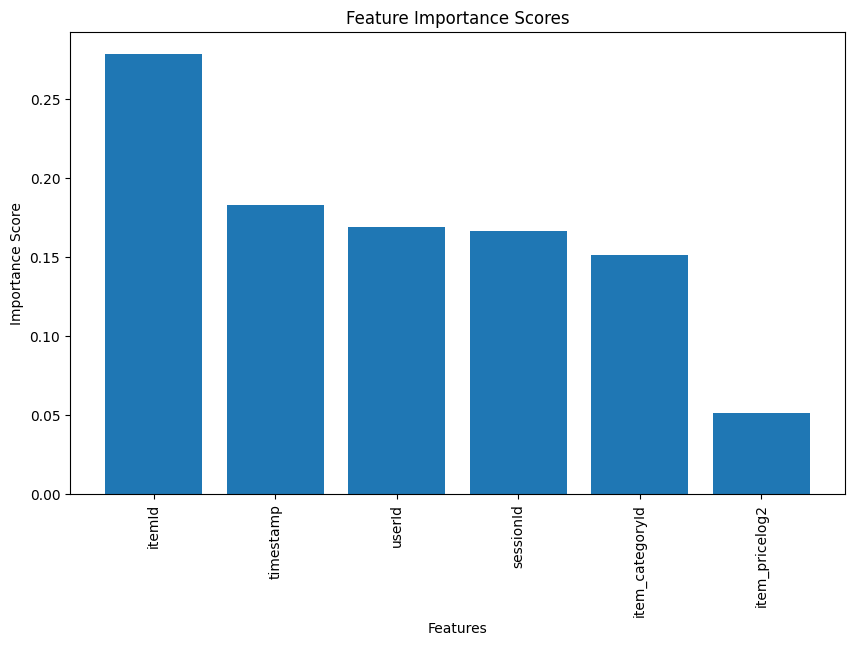

In [6]:
import matplotlib.pyplot as plt

def plot_feature_importance(model, feature_names, top_k=None):
    importance_scores = model.feature_importances_
    # Sort feature importance scores and feature names
    sorted_indices = importance_scores.argsort()[::-1]
    sorted_names = [feature_names[i] for i in sorted_indices]
    sorted_scores = importance_scores[sorted_indices]

    if top_k is not None:
        sorted_scores = sorted_scores[:top_k]
        sorted_names = sorted_names[:top_k]
    
    # Plot bar chart
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(sorted_names)), sorted_scores, align='center')
    plt.xticks(range(len(sorted_names)), sorted_names, rotation=90)
    plt.xlabel('Features')
    plt.ylabel('Importance Score')
    plt.title('Feature Importance Scores')
    plt.show()

plot_feature_importance(model, X_train.columns)

## Inter-row dependencies

The key idea to enhance the performance is to leverage the inter-dependencies among different events. For example, whether a user will click a product could be related to how well the product was accepted in the past (from past events that interact with the same product). By modeling those dependencies as graphs, our tool can generate features for a more accurate prediction.

To achieve that, we first treat all the ID columns (`queryId`, `itemId`, `sessionId`, `userId`) in the `Event` table as foreign keys, so that two rows sharing the same IDs are linked together. We have already finished this for you and you can find the definition from the dataset metadata.

In [47]:
import json
print(dataset.metadata.json(indent=2))

{
  "dataset_name": "diginetica-events",
  "tables": [
    {
      "name": "Event",
      "source": "data/events.pqt",
      "format": "parquet",
      "columns": [
        {
          "name": "queryId",
          "dtype": "foreign_key",
          "link_to": "Query.id"
        },
        {
          "name": "itemId",
          "dtype": "foreign_key",
          "link_to": "Product.id"
        },
        {
          "name": "timestamp",
          "dtype": "datetime"
        },
        {
          "name": "action_type",
          "dtype": "category"
        },
        {
          "name": "sessionId",
          "dtype": "foreign_key",
          "link_to": "Session.id"
        },
        {
          "name": "userId",
          "dtype": "foreign_key",
          "link_to": "User.id"
        },
        {
          "name": "query_duration",
          "dtype": "float"
        },
        {
          "name": "query_categoryId",
          "dtype": "category"
        },
        {
          "name": "

Use the code below to visualize the schema for a better understanding.

In [18]:
from sqlalchemy import create_engine
from sqlalchemy_schemadisplay import create_schema_graph
# Use the sqlalchemy_metadata attribute to get metadata in sqlalchemy format.
sa_metadata = dataset.sqlalchemy_metadata
graph = create_schema_graph(engine=create_engine('sqlite://'),  # Use a temporary in-memory sqlite db.
                            metadata=sa_metadata,
                            show_datatypes=True,                # The image would show datatypes
                            show_indexes=True,                  # The image would show index names and unique constraints
                            rankdir='LR',                       # From left to right, instead of top to bottom
                            concentrate=False)                  # Don't try to join the relation lines together

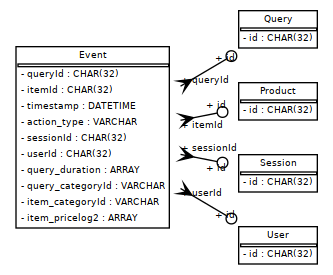

In [19]:
from IPython.display import Image, display

plt = Image(graph.create_png())
display(plt)

## Graph-based Featurization

Our tool has embeded solutions that leverages inter-row dependencies to generate meaningful features, an algorithm called Deep Feature Synthesis (DFS). It can be done in two steps.

**Step.1 Pre-DFS featurization**

In [20]:
!python -m tab2graph.main preprocess diginetica-events transform ../diginetica-events-pre-dfs -c ../configs/transform/pre-dfs.yaml

[I][2024-05-07 15:49:16,preprocess.py:49] Load solution configuration file: ../configs/transform/pre-dfs.yaml.
[D][2024-05-07 15:49:16,preprocess.py:52] Config:
{"transforms": [{"name": "handle_dummy_table", "config": {}}, {"name": "key_mapping", "config": {}}, {"name": "column_transform_chain", "config": {"transforms": [{"name": "canonicalize_numeric"}, {"name": "canonicalize_datetime"}, {"name": "glove_text_embedding"}]}}]}
[I][2024-05-07 15:49:16,preprocess.py:54] Loading data ...
[I][2024-05-07 15:49:21,preprocess.py:57] Creating preprocess ...
[D][2024-05-07 15:49:21,composite.py:38] [CanonicalizeNumericConfig(), CanonicalizeDatetimeConfig(), GloveTextEmbeddingTransformConfig(model_name='glove-twitter', dim=100, max_num_procs=16)]
[D][2024-05-07 15:49:21,transform_preprocess.py:89] Fit & transform RDB data.
[I][2024-05-07 15:49:21,dummy_table.py:61] Add dummy table 'Query' with PK column 'id'.
[I][2024-05-07 15:49:26,dummy_table.py:61] Add dummy table 'Product' with PK column 'id'

**Step.2 Deep Feature Synthesis**. Here we set the DFS depth to be two, meaning it will traverse to tables up to two hops from the event table.

In [21]:
!python -m tab2graph.main preprocess ../diginetica-events-pre-dfs dfs ../diginetica-events-post-dfs-2 -c ../configs/dfs/dfs-2-sql.yaml

[I][2024-05-07 15:50:51,preprocess.py:49] Load solution configuration file: ../configs/dfs/dfs-2-sql.yaml.
[D][2024-05-07 15:50:51,preprocess.py:52] Config:
{"dfs": {"agg_primitives": ["max", "min", "mean", "count", "mode", "concat", "join", "arraymax", "arraymin", "arraymean"], "max_depth": 2, "use_cutoff_time": true, "engine": "dfs2sql", "engine_path": "/tmp/duck.db"}}
[I][2024-05-07 15:50:51,preprocess.py:54] Loading data ...
[I][2024-05-07 15:50:59,preprocess.py:57] Creating preprocess ...
[I][2024-05-07 15:50:59,dfs_preprocess.py:50] Running DFS for task ctr ...
[D][2024-05-07 15:50:59,core.py:291]  Add table "Event".
[D][2024-05-07 15:50:59,core.py:299]    Parse column "queryId".
[D][2024-05-07 15:50:59,core.py:299]    Parse column "itemId".
[D][2024-05-07 15:50:59,core.py:299]    Parse column "timestamp".
[D][2024-05-07 15:50:59,core.py:299]    Parse column "action_type".
[D][2024-05-07 15:50:59,core.py:299]    Parse column "sessionId".
[D][2024-05-07 15:50:59,core.py:299]    Pa

## Prediction on the augmented table

In [48]:
# Load the augmented data.
dataset_dfs = dbinfer_bench.load_rdb_data('../diginetica-events-post-dfs-2')
ctr_task_dfs = dataset_dfs.get_task('ctr')
train_df_dfs = pd.DataFrame(ctr_task_dfs.train_set)
val_df_dfs = pd.DataFrame(ctr_task_dfs.validation_set)
test_df_dfs = pd.DataFrame(ctr_task_dfs.test_set)

print(train_df_dfs.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 37 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Session.COUNT(Event)                  90000 non-null  float32       
 1   Session.MAX(Event.item_pricelog2)     12853 non-null  float32       
 2   Session.MAX(Event.query_duration)     12446 non-null  float32       
 3   Session.MEAN(Event.item_pricelog2)    12853 non-null  float32       
 4   Session.MEAN(Event.query_duration)    12446 non-null  float32       
 5   Session.MIN(Event.item_pricelog2)     12853 non-null  float32       
 6   Session.MIN(Event.query_duration)     12446 non-null  float32       
 7   Session.MODE(Event.action_type)       12853 non-null  object        
 8   Session.MODE(Event.item_categoryId)   12853 non-null  object        
 9   Session.MODE(Event.query_categoryId)  12446 non-null  object        
 10

You can see that the train/validation/test table has been augmented with more features calculated from rows sharing the same ID. Let's see how the random forest predictor performs this time.

In [45]:
from sklearn.impute import SimpleImputer

def map_str_to_int(df):
    str_map = {'query_result' : 0, 'view' : 1, 'click' : 2}
    for col in [
        'Session.MODE(Event.action_type)',
        'Session.MODE(Event.item_categoryId)',
        'Session.MODE(Event.query_categoryId)',
        'Product.MODE(Event.action_type)',
        'Product.MODE(Event.item_categoryId)',
        'Product.MODE(Event.query_categoryId)',
        'User.MODE(Event.action_type)',
        'User.MODE(Event.item_categoryId)',
        'User.MODE(Event.query_categoryId)',
    ]:
        df[col] = df[col].map(str_map).fillna(-1).astype(int)
    return df

# Initialize SimpleImputer with strategy='mean' to fill null values with mean
imputer = SimpleImputer(strategy='mean')

X_train_dfs = train_df_dfs.drop(columns=['clicked'])
X_train_dfs['timestamp'] = X_train_dfs['timestamp'].astype('int')
X_train_dfs = map_str_to_int(X_train_dfs)
X_train_dfs = pd.DataFrame(imputer.fit_transform(X_train_dfs), columns=X_train_dfs.columns)
y_train_dfs = train_df_dfs['clicked']

X_test_dfs = test_df_dfs.drop(columns=['clicked'])
X_test_dfs['timestamp'] = X_test_dfs['timestamp'].astype('int')
X_test_dfs = map_str_to_int(X_test_dfs)
X_test_dfs = pd.DataFrame(imputer.transform(X_test_dfs), columns=X_test_dfs.columns)
y_test_dfs = test_df_dfs['clicked']

model = fit_and_predict(X_train_dfs, y_train_dfs, X_test_dfs, y_test_dfs)

Accuracy: 0.6744


You can see that the accuracy is much better. We can then plot the top-10 most significant features.

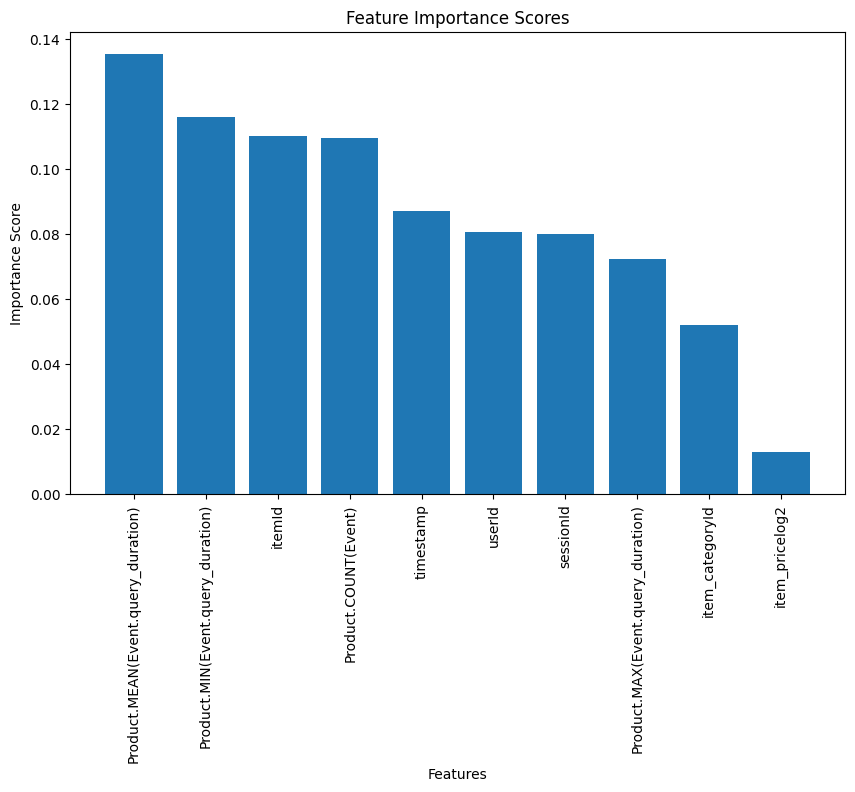

In [46]:
plot_feature_importance(model, X_train_dfs.columns, top_k=10)

It shows that:
- The statistics about query duration associated with the specific product (e.g., `Product.MEAN(Event.query_duration)`) is important for CTR prediction.
- Product popularity (`Product.COUNT(Event)`) is another important feature.